In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree




#os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())

C:\Users\cuent\En-Peu\notebooks


In [2]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_stored.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)

# Cargar datos de barranco
# Dataset original (con columna B)
file_path_2 = os.path.join(parent_directory, 'data', 'datos_combinados.csv')
data_original = pd.read_csv(file_path_2)

# --- PASO 2: Obtener los puntos del río ---
barranco = data_original[data_original['B'] == 1].copy()


# Verificar la estructura
print(data.info())
print(barranco.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   AC       64345 non-null  float64
 5   CIB      64345 non-null  float64
 6   CICCB    64345 non-null  float64
 7   CUS      64345 non-null  int64  
 8   DBB      64345 non-null  float64
 9   DOB      64345 non-null  float64
 10  OC       64345 non-null  int64  
 11  P        64345 non-null  float64
dtypes: float64(10), int64(2)
memory usage: 5.9 MB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2352 entries, 9038 to 50920
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   POINT_X   2352 non-null   float64
 1   POINT_Y   2352 non-null   float64
 2   PLA       2352 non-null   float

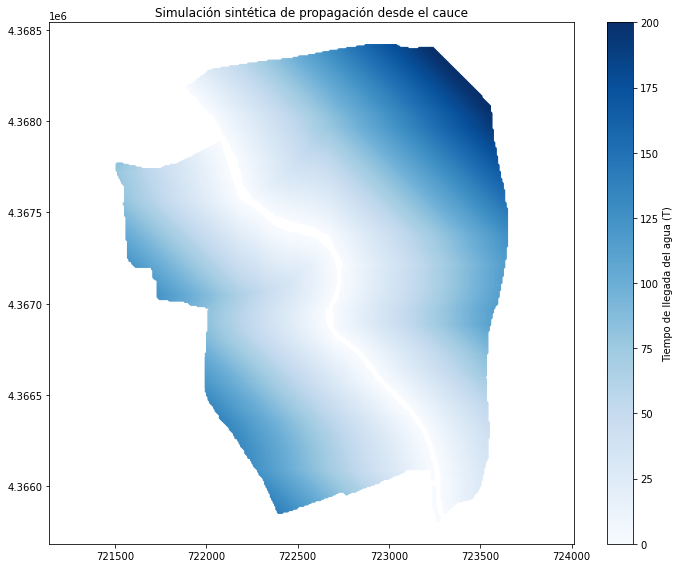

In [6]:
# Discretizar el territorio

# Coordenadas
coords = data[['POINT_X', 'POINT_Y']].values
tree = KDTree(coords, leaf_size=40)

# Usamos solo las coordenadas del río para marcar T=0
barranco_coords = barranco[['POINT_X', 'POINT_Y']].values

# Preparar dataset sin río para simulación
data['T'] = np.inf  # Tiempo de llegada inicial: infinito
tree = KDTree(data[['POINT_X', 'POINT_Y']].values, leaf_size=40)

# Buscar las celdas más cercanas al cauce y asignarles T=0
dist, ind = tree.query(barranco_coords, k=1)
cauce_indices = np.unique(ind.flatten())
data.loc[cauce_indices, 'T'] = 0  # Tiempo 0: contacto con el cauce

# Simulación de propagación (anillos T+1, T+2...)
max_t = 200  # aumentar para propagar más lejos
radio = 10  # Radio en metros para buscar vecinos (resolucion de 10x10)

for t in range(1, max_t + 1):
    puntos_t_previos = data[data['T'] == t - 1][['POINT_X', 'POINT_Y']].values
    if len(puntos_t_previos) == 0:
        break
    for punto in puntos_t_previos:
        indices_vecinos = tree.query_radius([punto], r=radio)[0]
        for idx in indices_vecinos:
            if data.loc[idx, 'T'] == np.inf:
                data.loc[idx, 'T'] = t

# --- PASO 5: Visualizar el resultado ---
plt.figure(figsize=(10, 8))
plt.scatter(data['POINT_X'], data['POINT_Y'], c=data['T'], cmap='Blues', s=10)
plt.colorbar(label='Tiempo de llegada del agua (T)')
plt.title("Simulación sintética de propagación desde el cauce")
plt.axis('equal')
plt.tight_layout()
plt.show()





Ahora que ya hay una variable T que indica el tiempo que tarda el agua en llegar a cada coordenada, se puede entrenar un modelo ML con variables geoespaciales que digan por dónde irá el agua

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Filtrar solo los puntos donde T fue asignado (es decir, que se inundaron en algún paso)
model_data = data[data['T'] < np.inf].copy()

# Variables predictoras
X = model_data[['A', 'AC', 'CIB', 'CICCB', 'CUS', 'DBB', 'DOB', 'OC', 'P']]

# Variable objetivo
y = model_data['T']

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
rf_T = RandomForestRegressor(n_estimators=200, random_state=42)
rf_T.fit(X_train, y_train)

# Predicción
y_pred = rf_T.predict(X_test)

# Evaluación
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE del modelo de T: {rmse:.2f}")
print(f"R² del modelo de T: {r2:.2f}")

RMSE del modelo de T: 0.39
R² del modelo de T: 1.00


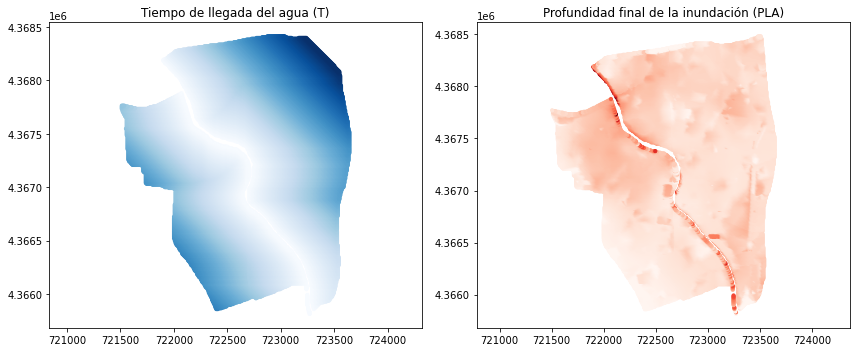

In [12]:
plt.figure(figsize=(12, 5))

# Mapa de T
plt.subplot(1, 2, 1)
plt.scatter(data['POINT_X'], data['POINT_Y'], c=data['T'], cmap='Blues', s=10)
plt.title("Tiempo de llegada del agua (T)")
plt.axis('equal')

# Mapa de PLA
plt.subplot(1, 2, 2)
plt.scatter(data['POINT_X'], data['POINT_Y'], c=data['PLA'], cmap='Reds', s=10)
plt.title("Profundidad final de la inundación (PLA)")
plt.axis('equal')

plt.tight_layout()
plt.show()

In [13]:
# Suponiendo que el agua baja hacia el sur (ajustar según el mapa)
barranco = data_original[data_original['B'] == 1].copy()
barranco_sorted = barranco.sort_values(by='POINT_Y', ascending=False).reset_index(drop=True)

# Añadir distancia acumulada (proxy del tiempo)
from scipy.spatial.distance import euclidean

distancia = [0]
for i in range(1, len(barranco_sorted)):
    p1 = (barranco_sorted.loc[i-1, 'POINT_X'], barranco_sorted.loc[i-1, 'POINT_Y'])
    p2 = (barranco_sorted.loc[i, 'POINT_X'], barranco_sorted.loc[i, 'POINT_Y'])
    distancia.append(distancia[-1] + euclidean(p1, p2))

barranco_sorted['dist_rio'] = distancia

In [14]:
from sklearn.ensemble import RandomForestRegressor

X = barranco_sorted[['dist_rio', 'A', 'AC', 'CIB', 'CICCB', 'CUS', 'DBB', 'DOB', 'OC', 'P']]
y = barranco_sorted['PLA']

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

y_pred = model.predict(X)
barranco_sorted['PLA_pred'] = y_pred